**FOLDER CREATION**

In [ ]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("app", exist_ok=True)

with open("README.md", "w") as f:
    f.write("# Credit Scoring Model Project\n")

**IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

**DATASET UPLOAD**

In [ ]:
df = pd.read_csv("credit_risk_dataset.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


**DATA PREPROCESSING**

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
df.fillna({
    'person_emp_length': df['person_emp_length'].median(),
    'loan_int_rate': df['loan_int_rate'].median()
}, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**MODEL TRAINING**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**EVALUATION**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

Accuracy: 0.9295688200092067

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96      5072
           1       0.96      0.71      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517

ROC-AUC Score: 0.8508266430528418


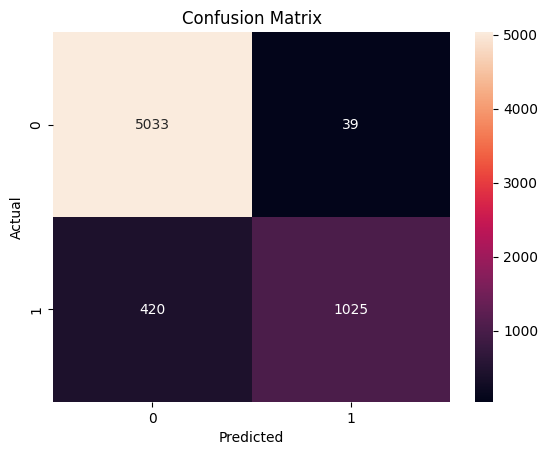

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**SAVE MODEL**

In [ ]:
import joblib

joblib.dump(rf, "models/credit_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

**BUILD UI**

In [ ]:
!pip install gradio

In [ ]:
import os
print(os.listdir())

['.config', 'app', 'data', 'models', 'credit_risk_dataset.csv', 'BG1.jpg', 'README.md', 'sample_data']


In [ ]:
import gradio as gr
import numpy as np
import joblib
import base64

# Load model
model = joblib.load("models/credit_model.pkl")
scaler = joblib.load("models/scaler.pkl")

# Convert image
def get_base64_image(image_path):
    with open(image_path, "rb") as img:
        return base64.b64encode(img.read()).decode()

BG1_image = get_base64_image("BG1.jpg")

# Prediction function
def predict_credit(
    age, income, home, emp_len, intent, grade,
    loan_amnt, int_rate, percent_income, default_hist, cred_len
):
    data = np.array([[age, income, home, emp_len, intent, grade,
                      loan_amnt, int_rate, percent_income,
                      default_hist, cred_len]])

    data = scaler.transform(data)
    prediction = model.predict(data)[0]

    return "❌ High Risk" if prediction == 1 else "✅ Low Risk"

# Dropdowns
home_options = ["RENT", "OWN", "MORTGAGE", "OTHER"]
intent_options = ["PERSONAL", "EDUCATION", "MEDICAL", "VENTURE", "HOMEIMPROVEMENT", "DEBTCONSOLIDATION"]
grade_options = ["A", "B", "C", "D", "E", "F", "G"]
default_options = ["No", "Yes"]

def map_inputs(age, income, home, emp_len, intent, grade,
               loan_amnt, int_rate, percent_income, default_hist, cred_len):

    home_map = {v:i for i,v in enumerate(home_options)}
    intent_map = {v:i for i,v in enumerate(intent_options)}
    grade_map = {v:i for i,v in enumerate(grade_options)}
    default_map = {"No":0, "Yes":1}

    return predict_credit(
        age, income, home_map[home], emp_len,
        intent_map[intent], grade_map[grade],
        loan_amnt, int_rate, percent_income,
        default_map[default_hist], cred_len
    )

# 🎨 FORCE BACKGROUND USING HTML
background_html = f"""
<style>
.gradio-container {{
    background: url("data:image/jpg;base64,{BG1_image}") no-repeat center center fixed !important;
    background-size: cover !important;
}}

.form-container {{
    background: rgba(0,0,0,0.5);
    padding: 20px;
    border-radius: 15px;
}}
</style>
"""

# UI
with gr.Blocks() as demo:

    gr.HTML(background_html)

    gr.Markdown("# 💳 Credit Risk Prediction Dashboard")
    gr.Markdown("### 🏦 AI Loan Approval System")

    with gr.Group(elem_classes="form-container"):

        with gr.Row():
            age = gr.Number(label="Age")
            income = gr.Number(label="Income")

        with gr.Row():
            home = gr.Dropdown(home_options, label="Home Ownership")
            emp_len = gr.Number(label="Employment Length")

        with gr.Row():
            intent = gr.Dropdown(intent_options, label="Loan Purpose")
            grade = gr.Dropdown(grade_options, label="Loan Grade")

        with gr.Row():
            loan_amnt = gr.Number(label="Loan Amount")
            int_rate = gr.Number(label="Interest Rate")

        with gr.Row():
            percent_income = gr.Number(label="Percent Income")
            default_hist = gr.Dropdown(default_options, label="Default History")

        cred_len = gr.Number(label="Credit History Length")

        btn = gr.Button("🚀 Predict")

        output = gr.Textbox(label="Result")

        btn.click(
            fn=map_inputs,
            inputs=[age, income, home, emp_len, intent, grade,
                    loan_amnt, int_rate, percent_income, default_hist, cred_len],
            outputs=output
        )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d2442deffc4170a102.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
